# Predictive Analytics Midterm — Bank Marketing
**Titanio Yudista · 24120500031 · Cakrawala University**

Notebook ini adalah laporan klasifikasi retrospektif atas `bank-additional-full.csv`. Jalankan dari root folder proyek dengan **Restart Runtime → Run All**. Semua hasil numerik di bawah dihitung dari data terlampir; seed = 42. Ambang keputusan setiap model tetap 0,5.

## Setup
Instal dependensi dari `requirements.txt` jika belum tersedia, lalu jalankan seluruh sel. Data lokal diutamakan; fungsi akuisisi resmi di bawah hanya aktif jika CSV belum ada. Grafik disimpan ke `artifacts/figures/`.

In [12]:
from pathlib import Path
from datetime import datetime, timezone
from importlib import metadata
import hashlib
import io
import json
import platform
import time
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
ROOT = Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'artifacts'
FIG = ART / 'figures'
for directory in (DATA, ART, FIG):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

def save_fig(name):
    plt.savefig(FIG / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Python:', platform.python_version(), '|', platform.platform())

Python: 3.12.10 | Linux-7.0.0-34-generic-x86_64-with-glibc2.39


## 1. Project Overview
Tim pemasaran bank perlu memprioritaskan calon kontak untuk tawaran deposito berjangka. Pertanyaan analitiknya: **apakah suatu catatan calon kontak akan berakhir dengan langganan deposito**, memakai informasi yang diasumsikan tersedia menjelang kontak yang direncanakan? Target `y` adalah `yes=1`, `no=0`; ini klasifikasi biner. Unit analisis adalah satu catatan nasabah terkait kampanye/kontak, bukan nasabah unik yang teridentifikasi.

Pemangku kepentingan adalah pengelola kampanye pemasaran. *False positive* berarti menghubungi calon yang akhirnya tidak berlangganan; *false negative* berarti melewatkan calon yang mungkin berlangganan. Biaya kedua kesalahan belum diketahui sehingga precision dan recall diberi bobot sama melalui F1 kelas positif. `contact`, `month`, `day_of_week`, dan nomor kontak `campaign` diasumsikan sudah direncanakan, sedangkan indikator ekonomi harus tersedia pada saat keputusan. Ketersediaan itu perlu diverifikasi sebelum penggunaan nyata: dokumentasi sumber menyebut kanal, bulan, dan hari sebagai atribut kontak terakhir, sedangkan waktu rilis indikator ekonomi tidak diverifikasi pada data ini. Dataset anonim tanpa ID langsung, tetapi penggunaan atribut demografi tetap memerlukan pemeriksaan etika dan bias.

## 2. Dataset Description & Source
Sumber: Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing [Dataset]*. UCI Machine Learning Repository. DOI: [10.24432/C5K306](https://doi.org/10.24432/C5K306), [halaman dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing). Ini berbeda dari artikel Moro, Cortez, & Rita (2014), *A data-driven approach to predict the success of bank telemarketing*. Versi **additional full** berisi 41.188 catatan historis berurutan menurut waktu, Mei 2008–November 2010, dan 20 input plus target. Dokumentasi varian ada di `data/bank-additional-names.txt`.

| Kolom | Tipe | Arti / perlakuan |
|---|---|---|
| age | numerik | Usia, tahun |
| job | kategori | Pekerjaan |
| marital | kategori | Status perkawinan |
| education | kategori | Pendidikan |
| default | kategori | Status kredit macet, termasuk `unknown` |
| housing | kategori | Pinjaman perumahan |
| loan | kategori | Pinjaman pribadi |
| contact | kategori | Media kontak |
| month | kategori | Bulan kontak |
| day_of_week | kategori | Hari kontak |
| duration | numerik | Durasi kontak, detik; dikeluarkan karena belum diketahui sebelum kontak |
| campaign | numerik | Jumlah kontak kampanye termasuk kontak terakhir |
| pdays | numerik | Hari sejak kontak kampanye sebelumnya; 999 = belum pernah |
| previous | numerik | Jumlah kontak sebelum kampanye ini |
| poutcome | kategori | Hasil kampanye sebelumnya |
| emp.var.rate | numerik | Indikator variasi ketenagakerjaan |
| cons.price.idx | numerik | Indeks harga konsumen |
| cons.conf.idx | numerik | Indeks kepercayaan konsumen |
| euribor3m | numerik | Euribor 3 bulan |
| nr.employed | numerik | Indikator jumlah pekerja |
| y | target kategori | Berlangganan deposito, yes/no |

In [13]:
URL = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'
csv_path = DATA / 'bank-additional-full.csv'
names_path = DATA / 'bank-additional-names.txt'
source_path = DATA / 'source_metadata.json'

def acquire_official_data():
    if csv_path.exists() and names_path.exists():
        return
    last_error = None
    for attempt in range(3):
        try:
            with urllib.request.urlopen(URL, timeout=30) as response:
                archive = response.read()
            break
        except Exception as exc:
            last_error = exc
            time.sleep(2 * (attempt + 1))
    else:
        raise RuntimeError(f'Unduhan UCI gagal setelah 3 percobaan: {last_error}')
    with zipfile.ZipFile(io.BytesIO(archive)) as outer:
        matches = [p for p in outer.namelist() if Path(p).name == 'bank-additional.zip']
        if len(matches) != 1:
            raise ValueError(f'Arsip additional ambigu/tidak ditemukan: {matches}')
        nested = outer.read(matches[0])
    with zipfile.ZipFile(io.BytesIO(nested)) as inner:
        for filename, dest in [('bank-additional-full.csv', csv_path),
                               ('bank-additional-names.txt', names_path)]:
            matches = [p for p in inner.namelist() if Path(p).name == filename]
            if len(matches) != 1:
                raise ValueError(f'Member {filename} ambigu/tidak ditemukan: {matches}')
            dest.write_bytes(inner.read(matches[0]))
    source_path.write_text(json.dumps({
        'source_url': URL, 'dataset_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing',
        'doi': '10.24432/C5K306', 'variant': 'bank-additional-full.csv',
        'downloaded_at_utc': datetime.now(timezone.utc).isoformat(),
        'files': {p.name: {'bytes': p.stat().st_size,
                            'sha256': hashlib.sha256(p.read_bytes()).hexdigest()}
                  for p in (csv_path, names_path)}}, indent=2) + '\n')

acquire_official_data()
source = json.loads(source_path.read_text()) if source_path.exists() else {}
csv_sha = hashlib.sha256(csv_path.read_bytes()).hexdigest()
if source.get('files', {}).get(csv_path.name, {}).get('sha256') not in (None, csv_sha):
    raise ValueError('Checksum CSV berbeda dari source_metadata.json')
expected_columns = ['age','job','marital','education','default','housing','loan','contact',
                    'month','day_of_week','duration','campaign','pdays','previous','poutcome',
                    'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y']
df_raw = pd.read_csv(csv_path, sep=';')
assert df_raw.shape == (41188, 21), df_raw.shape
assert df_raw.columns.tolist() == expected_columns, df_raw.columns.tolist()
print('Shape:', df_raw.shape, '| SHA-256:', csv_sha)
print('Akses/unduh UTC:', source.get('downloaded_at_utc', 'tanggal tidak diketahui'))
display(df_raw.head(), df_raw.dtypes.to_frame('dtype'))

Shape: (41188, 21) | SHA-256: 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8
Akses/unduh UTC: 2026-09-25T08:20:23.989102+00:00


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,dtype
age,int64
job,str
marital,str
education,str
default,str
housing,str
loan,str
contact,str
month,str
day_of_week,str


## 3. Data Quality Assessment
Audit ini hanya mengecek integritas seluruh data. `unknown` adalah kategori eksplisit, bukan null yang otomatis diimputasi. `pdays=999` adalah sentinel, bukan umur kontak ekstrem. `duration` diketahui setelah panggilan sehingga dikeluarkan tanpa memakai korelasi target. Distribusi target ditampilkan sebagai pemeriksaan label; analisis hubungan fitur–target dilakukan setelah split.

,dtype,null,unknown,unique,nonfinite
age,int64,0,0,78,0
job,str,0,330,12,0
marital,str,0,80,4,0
education,str,0,1731,8,0
default,str,0,8597,3,0
housing,str,0,990,3,0
loan,str,0,990,3,0
contact,str,0,0,2,0
month,str,0,0,10,0
day_of_week,str,0,0,5,0


,count
age_le_0,0
campaign_lt_1,0
previous_lt_0,0
pdays_lt_0,0
pdays_999_sentinel,39673
unknown_target,0
exact_duplicates_21_columns,12


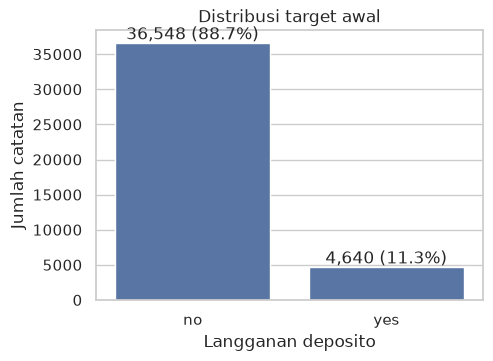

Keputusan: exact duplicate dihapus sebelum proyeksi; unknown dipertahankan; sentinel ditransformasi; outlier valid dipertahankan.


In [14]:
quality = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'null': df_raw.isna().sum(),
    'unknown': df_raw.eq('unknown').sum(),
    'unique': df_raw.nunique(dropna=False),
})
numeric_raw = df_raw.select_dtypes(include='number')
nonfinite = (~np.isfinite(numeric_raw.to_numpy())).sum(axis=0)
quality['nonfinite'] = pd.Series(nonfinite, index=numeric_raw.columns).reindex(quality.index).fillna(0).astype(int)
invalid = {
    'age_le_0': int((df_raw.age <= 0).sum()),
    'campaign_lt_1': int((df_raw.campaign < 1).sum()),
    'previous_lt_0': int((df_raw.previous < 0).sum()),
    'pdays_lt_0': int((df_raw.pdays < 0).sum()),
    'pdays_999_sentinel': int((df_raw.pdays == 999).sum()),
    'unknown_target': int((~df_raw.y.isin(['yes', 'no'])).sum()),
    'exact_duplicates_21_columns': int(df_raw.duplicated().sum()),
}
display(quality, pd.Series(invalid, name='count').to_frame())
if any(invalid[k] for k in ('age_le_0','campaign_lt_1','previous_lt_0','pdays_lt_0','unknown_target')) or quality.nonfinite.sum():
    raise ValueError('Ditemukan nilai invalid; periksa audit sebelum melanjutkan')
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df_raw.y.value_counts().reindex(['no','yes'])
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set(title='Distribusi target awal', xlabel='Langganan deposito', ylabel='Jumlah catatan')
for i, count in enumerate(counts):
    ax.text(i, count, f'{count:,} ({count/len(df_raw):.1%})', ha='center', va='bottom')
save_fig('01_target_raw.png')
print('Keputusan: exact duplicate dihapus sebelum proyeksi; unknown dipertahankan; sentinel ditransformasi; outlier valid dipertahankan.')

## 4. Data Preparation dan pemisahan
Duplikat identik dihapus atas **21 kolom asli**, sebagai kebijakan untuk catatan sama persis dan bukan bukti satu nasabah. Indeks asli dipertahankan untuk audit. Setelah `duration` dan target dikeluarkan, profil X identik dikelompokkan tanpa memakai label; label berbeda pada profil identik tetap disimpan. Fold pertama `StratifiedGroupKFold` dipakai sebagai holdout sekitar 20%. Lima fold baru pada development digunakan sama untuk semua model. Split acak bergrup ini menguji profil historis dalam periode yang sama, bukan masa depan; tanpa ID nasabah, nasabah berulang belum tentu terpisah.

In [15]:
df_clean = df_raw.drop_duplicates(keep='first').copy()
if df_clean.y.isna().any() or not df_clean.y.isin(['yes','no']).all():
    raise ValueError('Target harus lengkap dan hanya yes/no')
y = df_clean.y.map({'no':0,'yes':1}).astype(int)
X = df_clean.drop(columns=['y','duration']).copy()
X['was_previously_contacted'] = (X.pdays != 999).astype(int)
X['pdays_clean'] = X.pdays.mask(X.pdays == 999, 0)
X = X.drop(columns='pdays')
numeric_features = ['age','campaign','previous','emp.var.rate','cons.price.idx',
                    'cons.conf.idx','euribor3m','nr.employed','was_previously_contacted','pdays_clean']
categorical_features = ['job','marital','education','default','housing','loan',
                        'contact','month','day_of_week','poutcome']
assert X.shape[1] == 20 and set(numeric_features + categorical_features) == set(X.columns)
assert len(set(numeric_features) & set(categorical_features)) == 0
assert X.index.equals(y.index)

# factorize over all predictor columns, with a stable null marker; y is never part of grouping.
group_frame = X.astype(object).where(X.notna(), '<NULL>')
groups = pd.Series(pd.factorize(pd.MultiIndex.from_frame(group_frame), sort=False)[0],
                   index=X.index, name='group_id')
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dev_pos, test_pos = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[dev_pos], X.iloc[test_pos]
y_train, y_test = y.iloc[dev_pos], y.iloc[test_pos]
groups_train, groups_test = groups.iloc[dev_pos], groups.iloc[test_pos]
cv_splits = list(splitter.split(X_train, y_train, groups_train))
assert X_train.index.intersection(X_test.index).empty
assert set(groups_train).isdisjoint(set(groups_test))
assert set(y_train.unique()) == set(y_test.unique()) == {0,1}
val_counts = np.zeros(len(X_train), dtype=int)
fold_by_original = {}
for fold, (fit_idx, val_idx) in enumerate(cv_splits, 1):
    assert set(groups_train.iloc[fit_idx]).isdisjoint(set(groups_train.iloc[val_idx]))
    assert set(y_train.iloc[fit_idx].unique()) == set(y_train.iloc[val_idx].unique()) == {0,1}
    val_counts[val_idx] += 1
    fold_by_original.update(dict.fromkeys(X_train.index[val_idx], fold))
assert (val_counts == 1).all()
manifest = pd.DataFrame({'original_index': X.index, 'group_id': groups.values,
                         'split': np.where(X.index.isin(X_test.index), 'test', 'development'),
                         'cv_validation_fold': [fold_by_original.get(i, pd.NA) for i in X.index]})
manifest.to_csv(ART / 'split_manifest.csv', index=False)
cleaning_log = pd.DataFrame([
    {'step':'raw','rows_before':len(df_raw),'rows_after':len(df_raw),'decision':'CSV asli; tidak dimodifikasi'},
    {'step':'exact duplicate 21 columns','rows_before':len(df_raw),'rows_after':len(df_clean),'decision':'hapus catatan yang identik penuh; indeks asli disimpan'},
    {'step':'duration','rows_before':len(df_clean),'rows_after':len(df_clean),'decision':'hapus fitur pascakontak untuk mencegah leakage'},
    {'step':'pdays=999','rows_before':len(df_clean),'rows_after':len(df_clean),'decision':'indikator pernah dihubungi + pdays_clean; tanpa imputasi global'},
    {'step':'unknown/outlier','rows_before':len(df_clean),'rows_after':len(df_clean),'decision':'kategori unknown dan nilai ekstrem valid dipertahankan'},
])
cleaning_log.to_csv(ART / 'cleaning_log.csv', index=False)
display(cleaning_log)
print('Development:', len(X_train), 'positif:', f'{y_train.mean():.2%}',
      '| Test:', len(X_test), 'positif:', f'{y_test.mean():.2%}',
      '| Grup unik:', groups.nunique())
assert hashlib.sha256(csv_path.read_bytes()).hexdigest() == csv_sha

,step,rows_before,rows_after,decision
0,raw,41188,41188,CSV asli; tidak dimodifikasi
1,exact duplicate 21 columns,41188,41176,hapus catatan yang identik penuh; indeks asli ...
2,duration,41176,41176,hapus fitur pascakontak untuk mencegah leakage
3,pdays=999,41176,41176,indikator pernah dihubungi + pdays_clean; tanp...
4,unknown/outlier,41176,41176,kategori unknown dan nilai ekstrem valid diper...


Development: 32940 positif: 11.27% | Test: 8236 positif: 11.27% | Grup unik: 39167


## 5. Exploratory Data Analysis — development saja
Grafik dan tabel berikut memakai `X_train/y_train` saja. Kategori dengan jumlah kecil tidak digunakan sebagai alasan intervensi langsung. Korelasi antarfaktor ekonomi dapat membuat bobot fitur terbagi; asosiasi tidak menyiratkan sebab akibat.

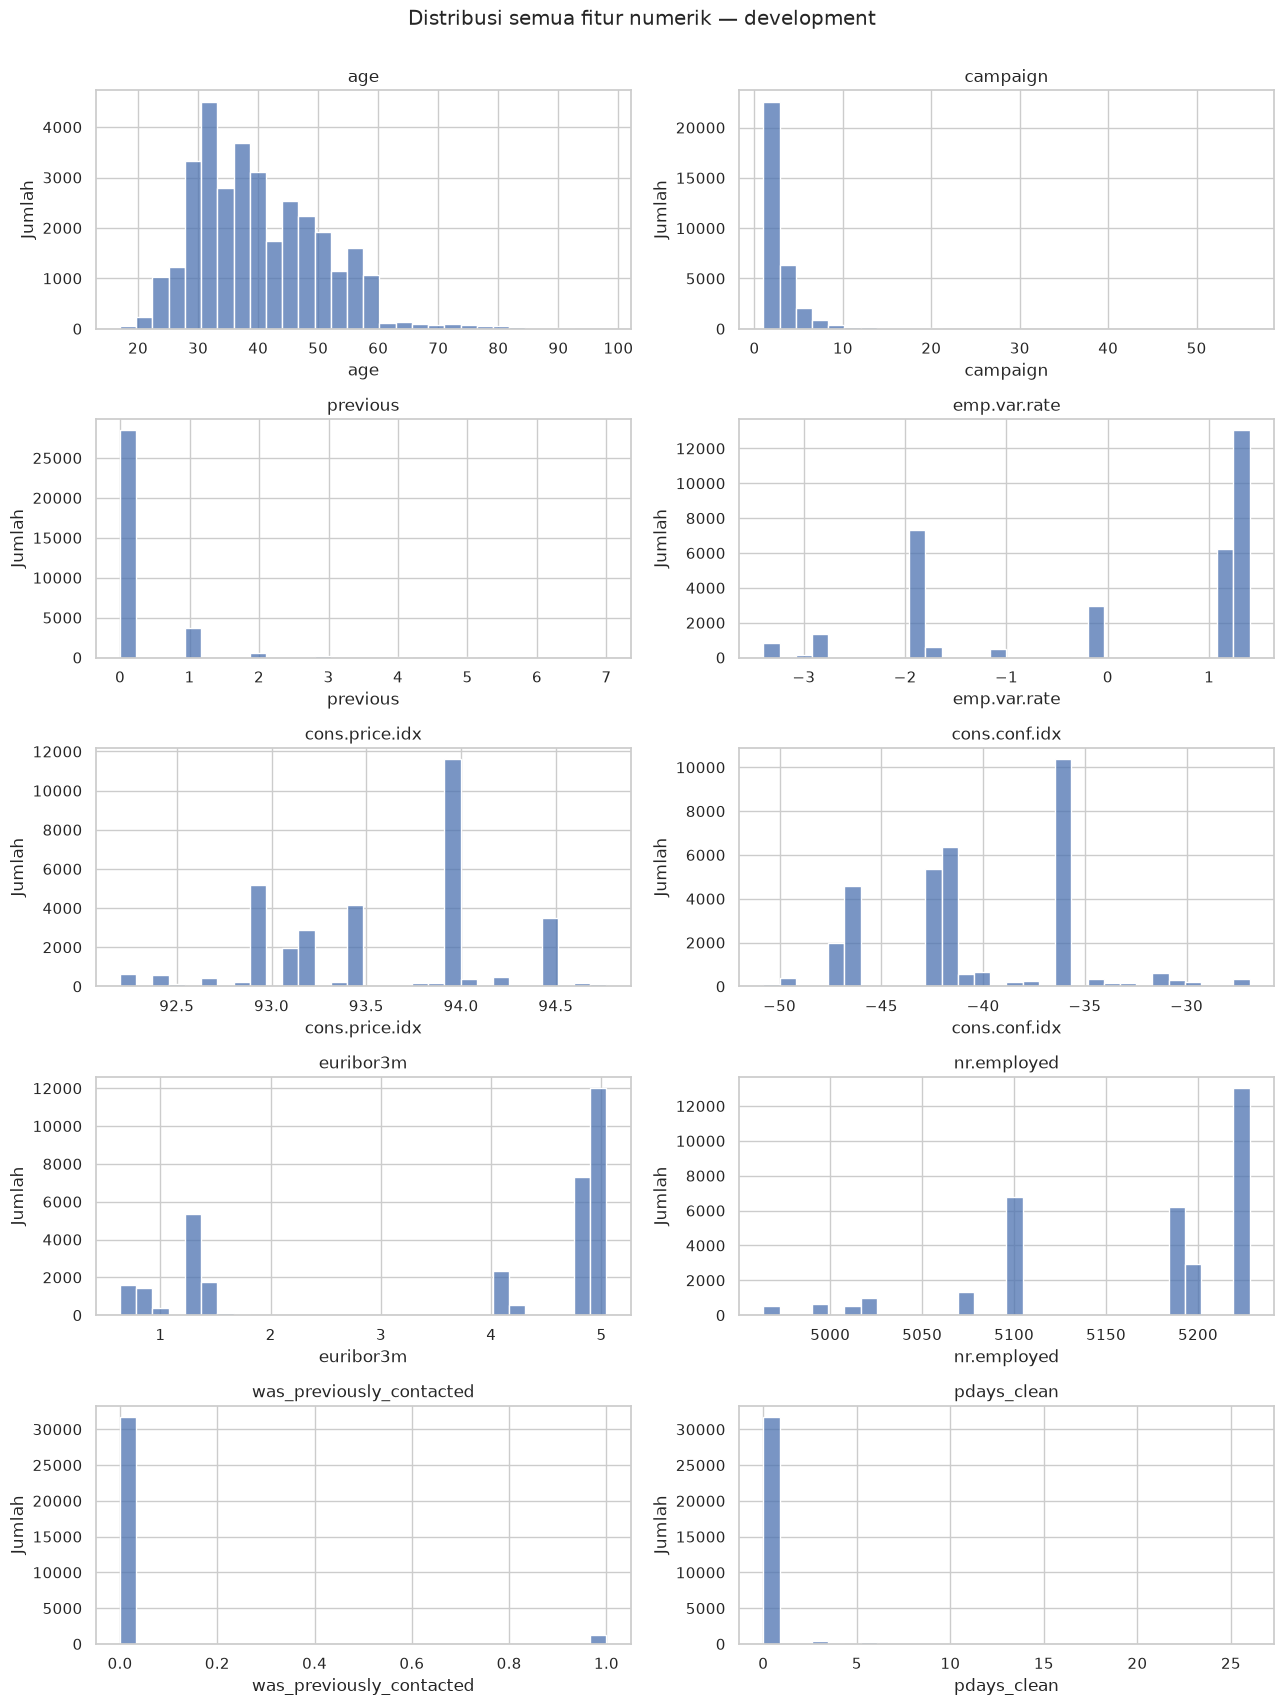

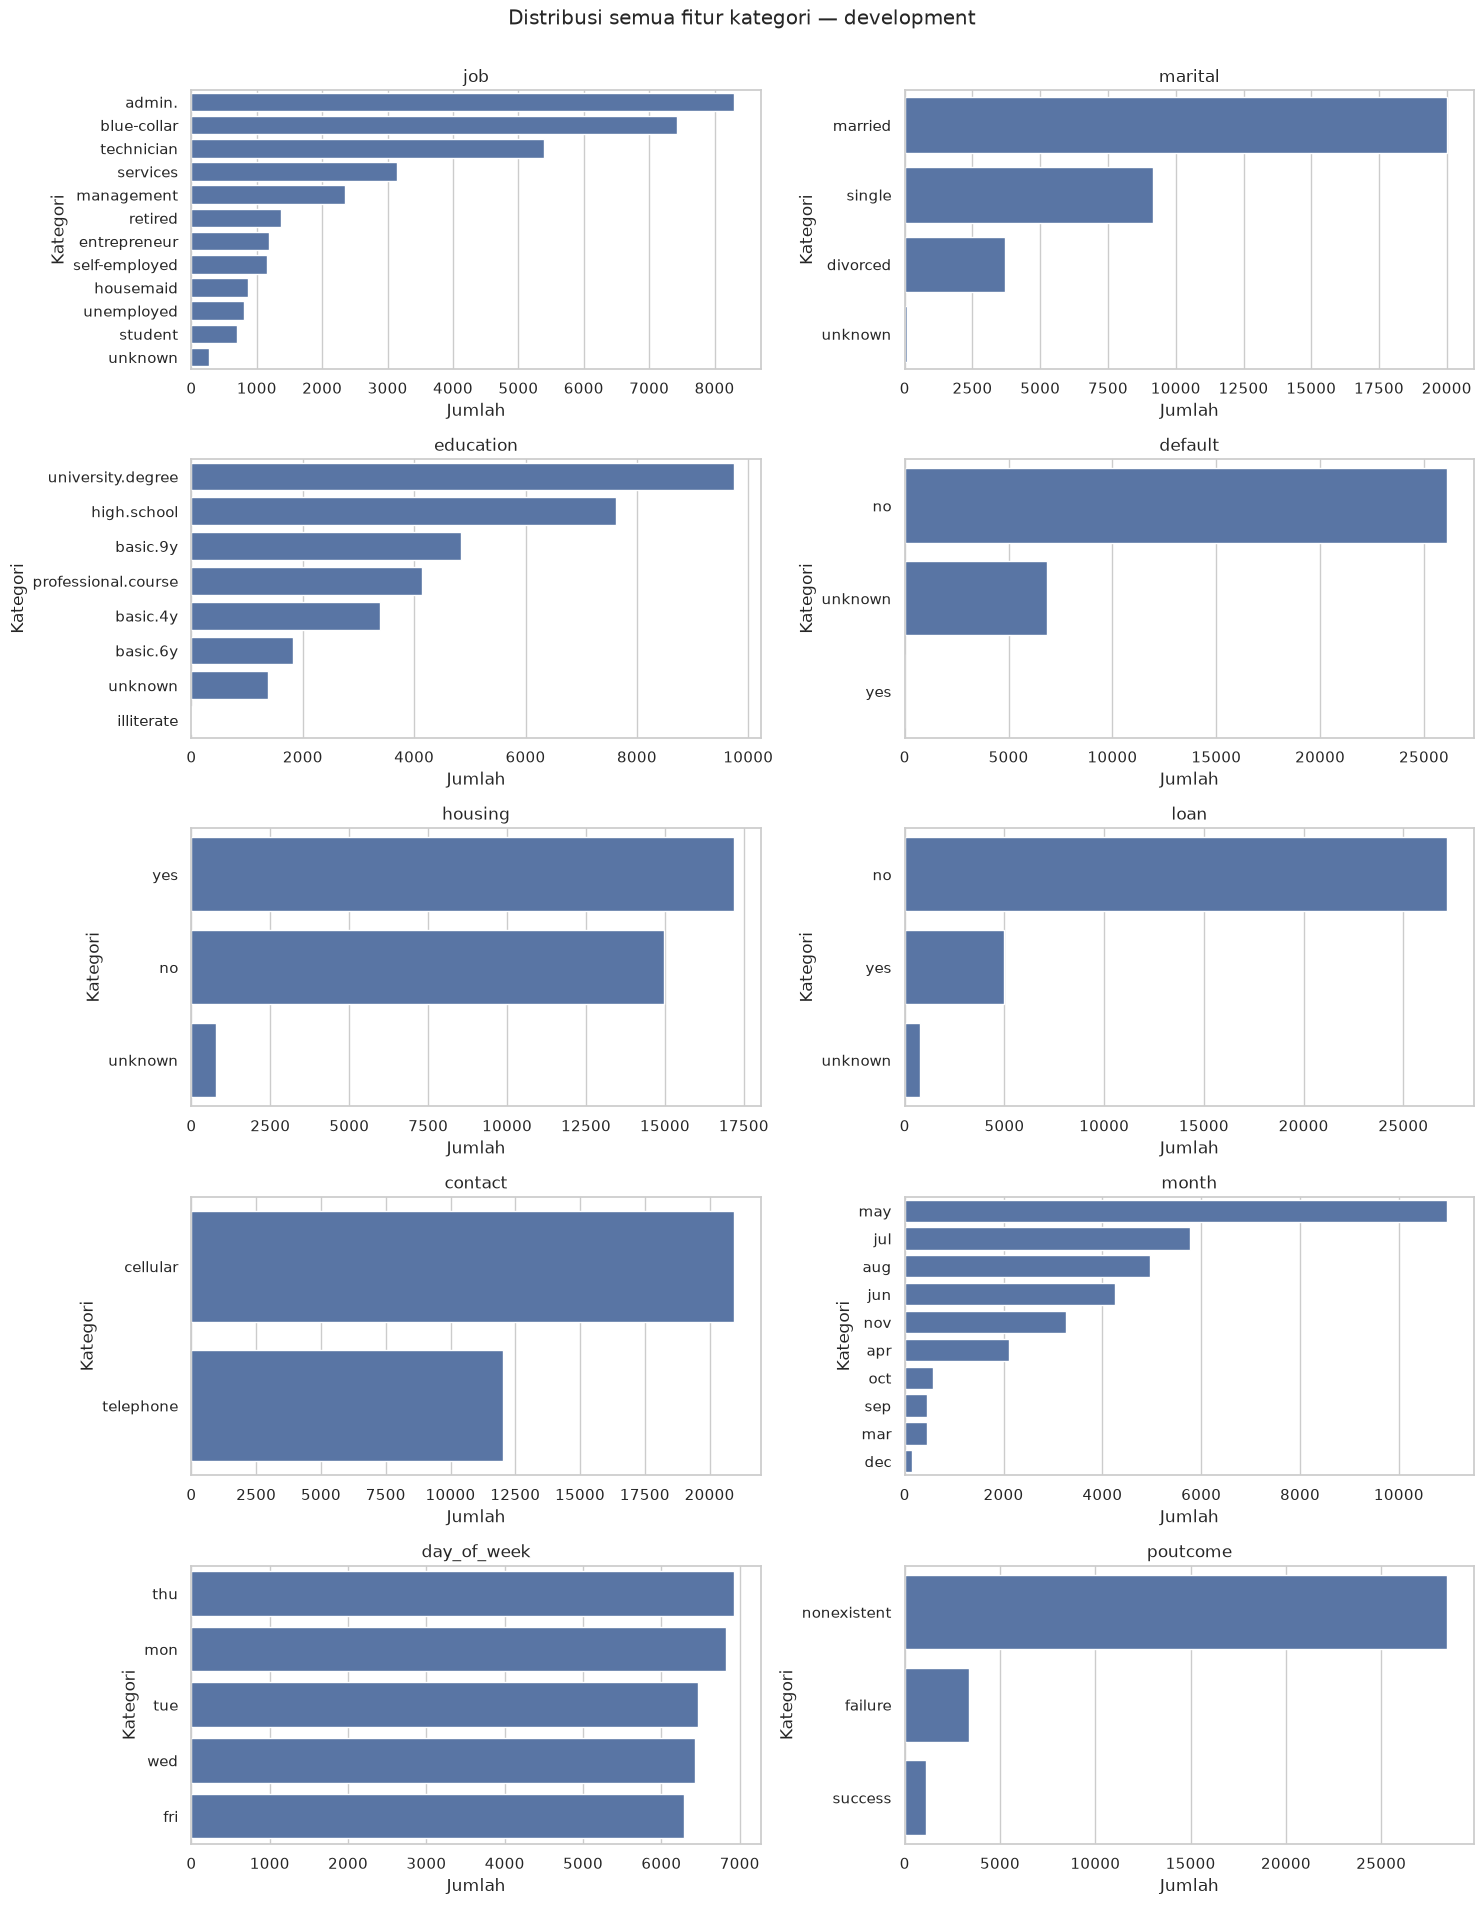

,feature,category,count,positive_rate
33,contact,cellular,20925,0.147431
34,contact,telephone,12015,0.052102
47,day_of_week,thu,6922,0.119763
46,day_of_week,mon,6822,0.098212
48,day_of_week,tue,6470,0.118393
49,day_of_week,wed,6433,0.116275
45,day_of_week,fri,6293,0.110917
24,default,no,26100,0.129004
25,default,unknown,6837,0.050314
26,default,yes,3,0.000000


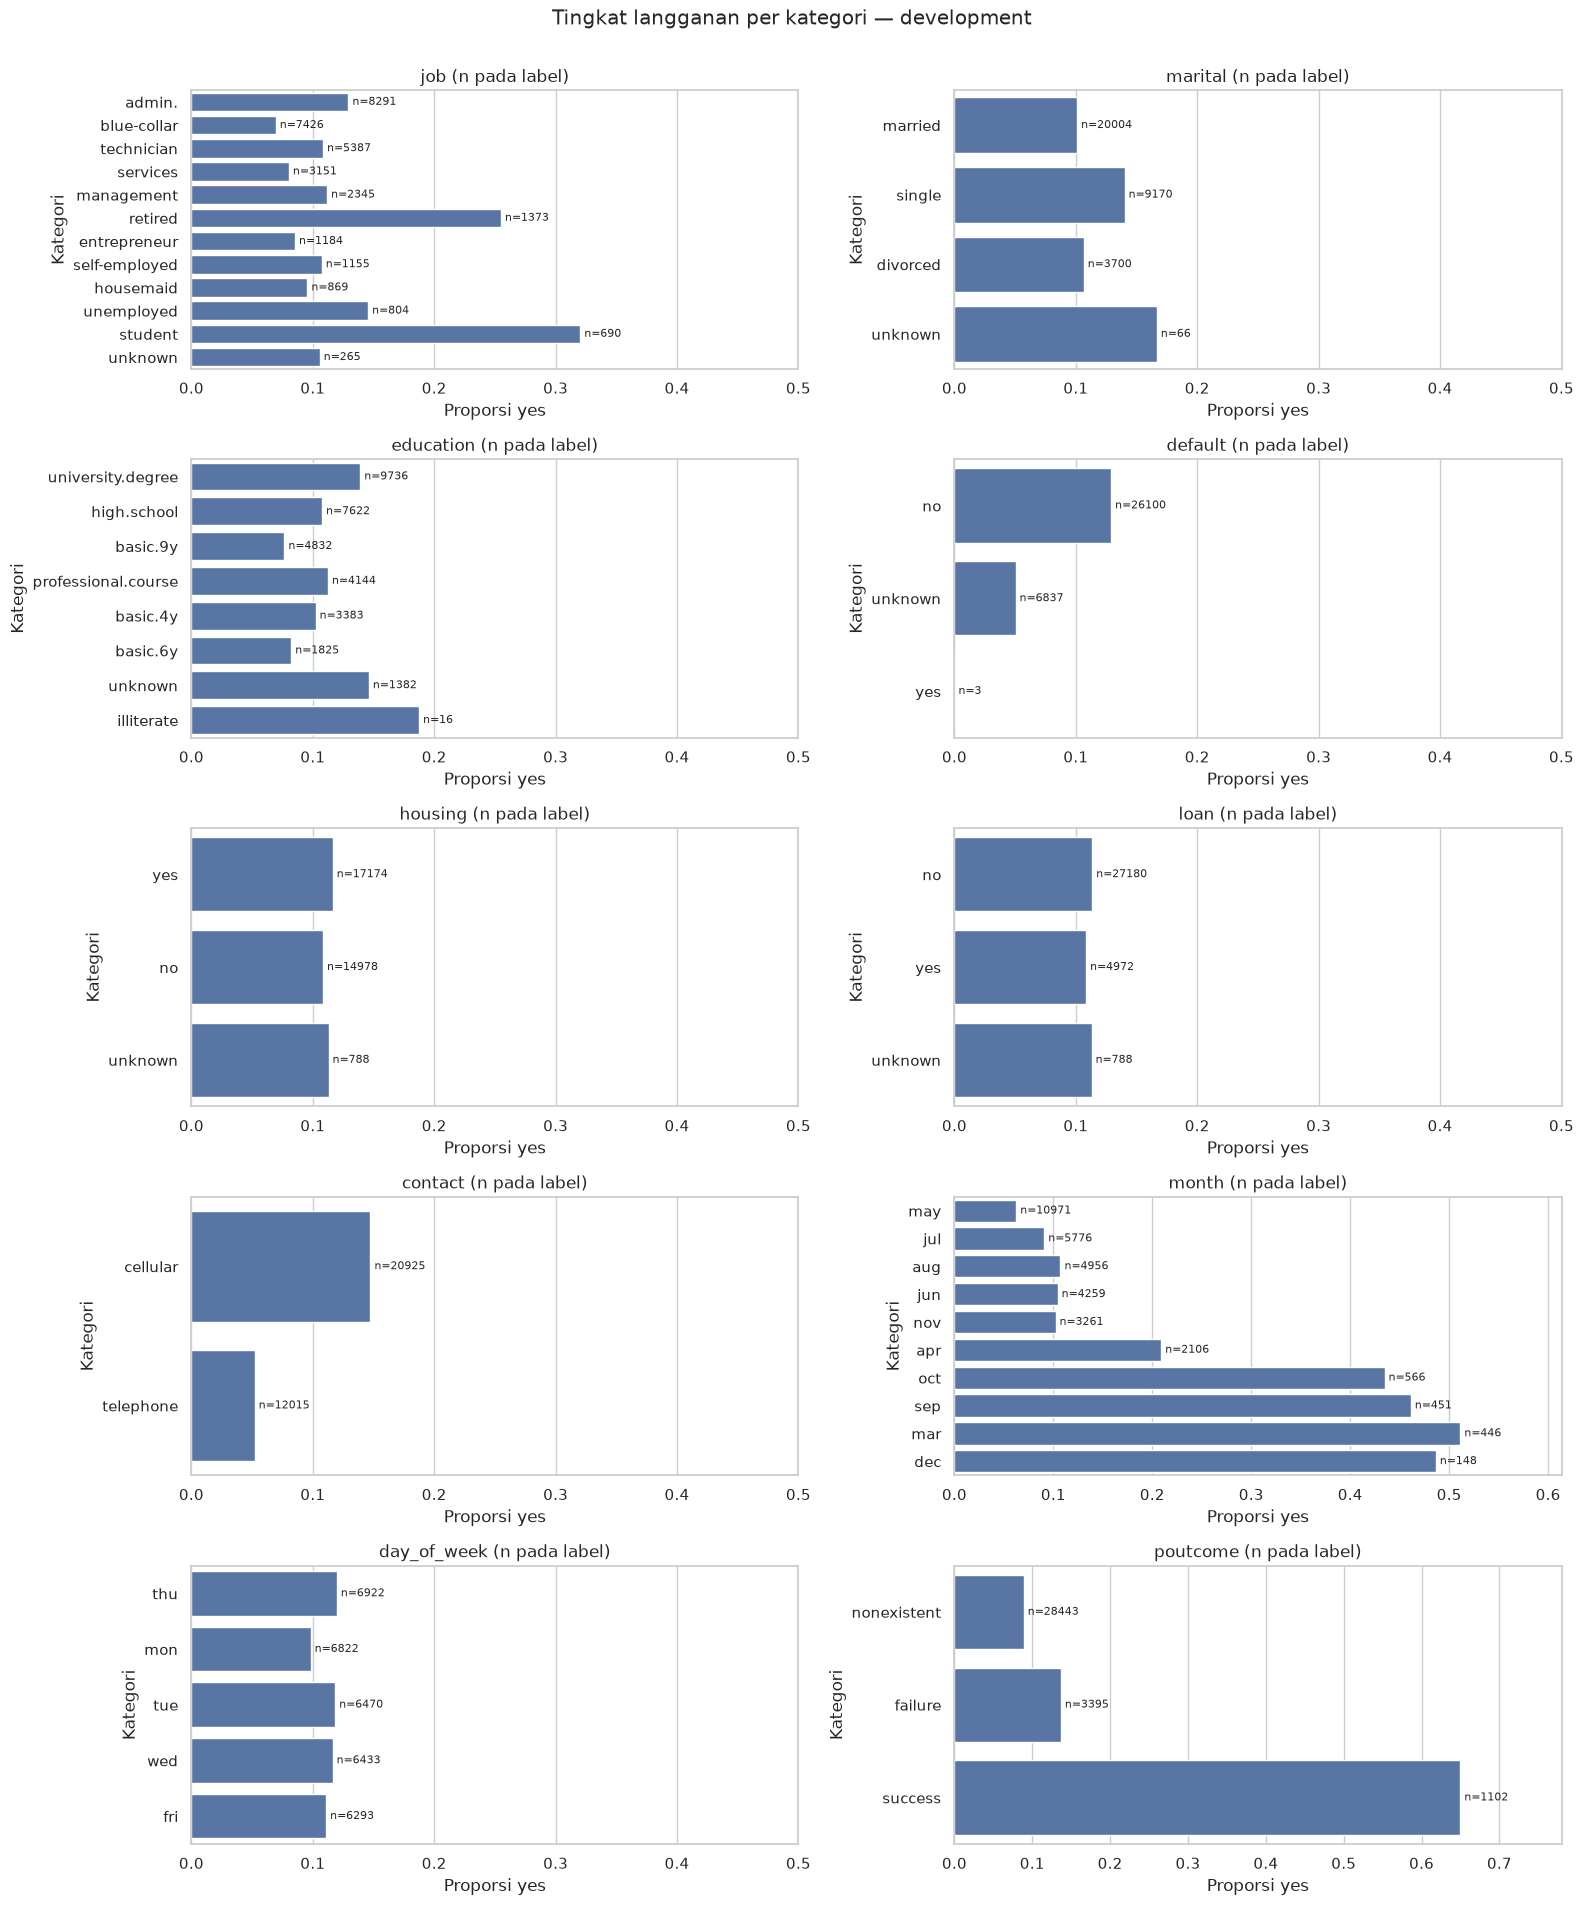

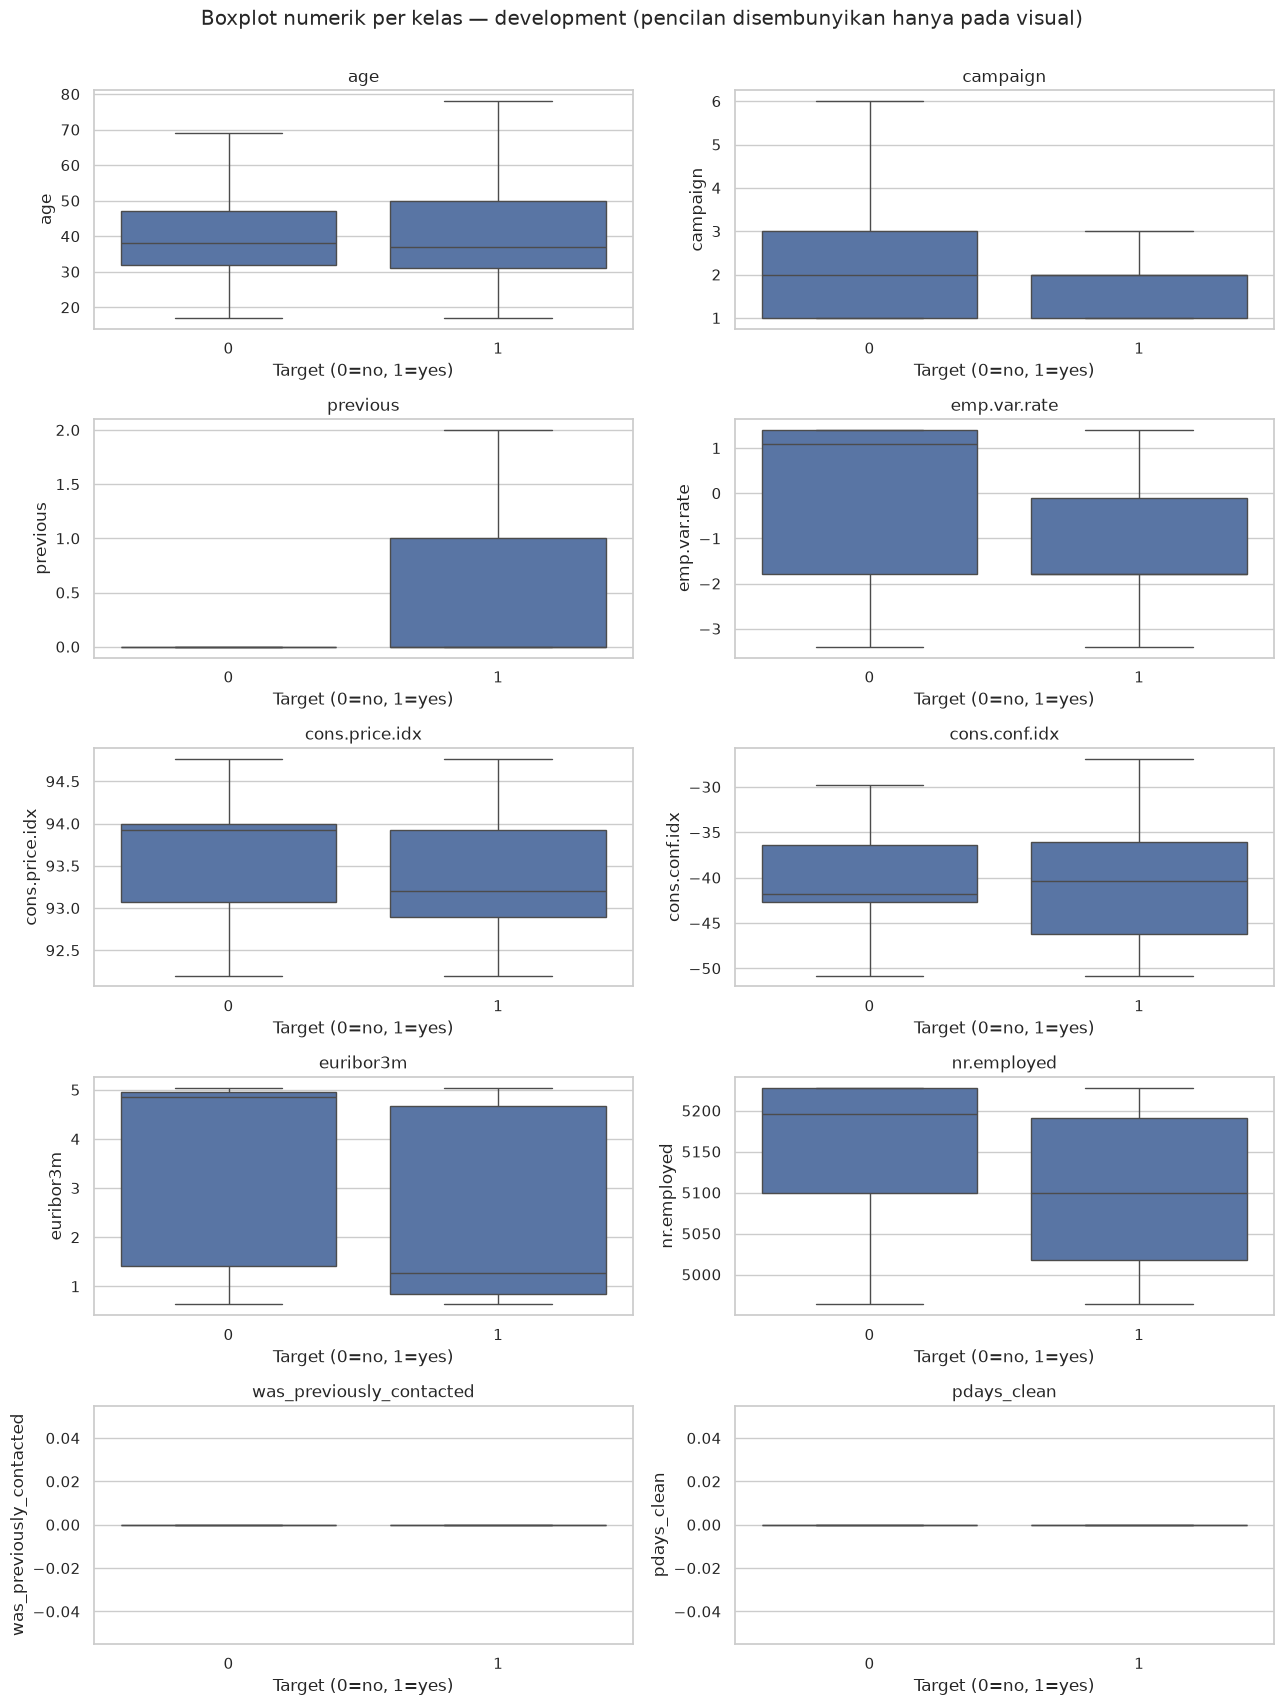

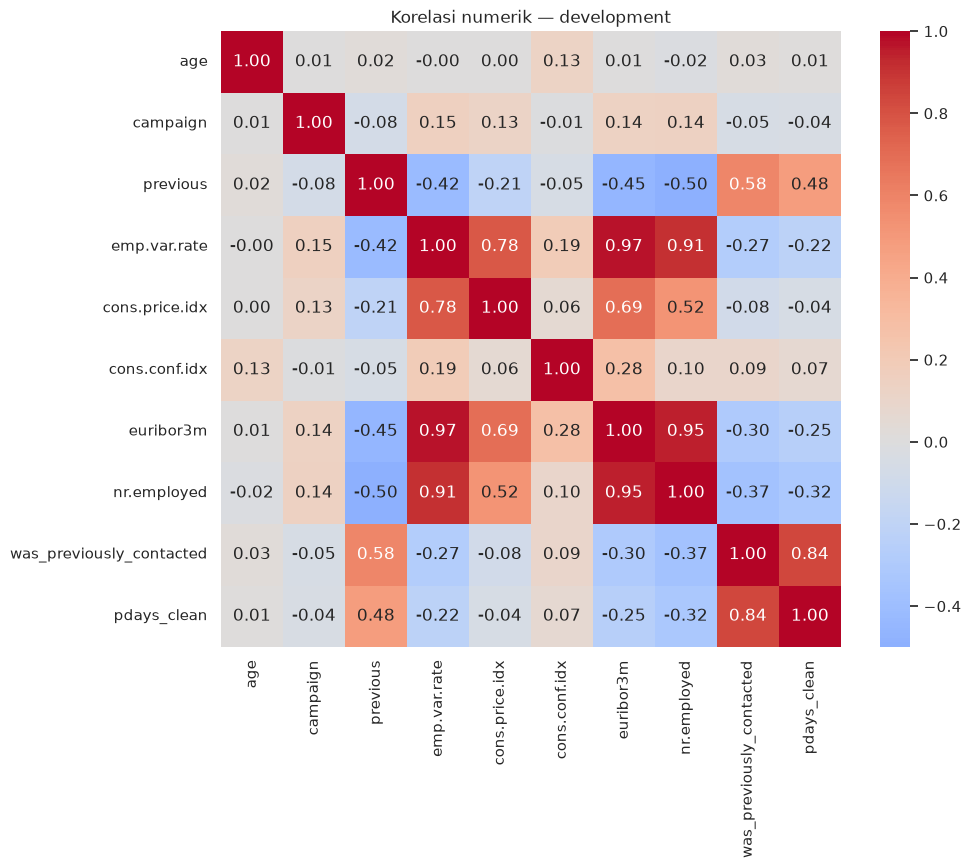

Lima insight dari grafik dan tabel development:
1. Gambar distribusi target: kelas positif 11.3%; accuracy mayoritas saja akan tampak tinggi, sehingga F1 positif dipakai.
2. Audit pdays asli dan histogram pdays_clean: sentinel 999 pada 96.3% development; indikator pernah dihubungi menjaga beda antara belum pernah dan 0 hari.
3. Grafik tingkat yes poutcome: success 65.0% (n=1102), nonexistent 8.9% (n=28443). Riwayat kampanye berasosiasi dengan target, bukan efek intervensi.
4. Boxplot dan heatmap: median euribor3m no=4.857, yes=1.266; |r| dengan emp.var.rate=0.97. Faktor ekonomi berkorelasi, sehingga importance individual perlu hati-hati.
5. Histogram/boxplot: campaign 1–56 dan age 17–98 dipertahankan; 2 kategori memiliki n<30, sehingga rate kategori kecil tidak dijadikan dasar keputusan.


,feature,category,count,positive_rate
26,default,yes,3,0.0000
20,education,illiterate,16,0.1875


In [16]:
eda = X_train.assign(y=y_train)
fig, axes = plt.subplots(5, 2, figsize=(13, 17))
for ax, feature in zip(axes.flat, numeric_features):
    sns.histplot(X_train[feature], bins=30, ax=ax)
    ax.set(title=feature, xlabel=feature, ylabel='Jumlah')
fig.suptitle('Distribusi semua fitur numerik — development', y=1.002)
fig.tight_layout()
save_fig('02_numeric_hist.png')

fig, axes = plt.subplots(5, 2, figsize=(15, 19))
for ax, feature in zip(axes.flat, categorical_features):
    vc = X_train[feature].fillna('missing').value_counts()
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax)
    ax.set(title=feature, xlabel='Jumlah', ylabel='Kategori')
fig.suptitle('Distribusi semua fitur kategori — development', y=1.002)
fig.tight_layout()
save_fig('03_categorical_counts.png')

rate_rows = []
for feature in categorical_features:
    table = eda.groupby(feature, dropna=False).y.agg(['count','mean']).reset_index()
    table['feature'] = feature
    table = table.rename(columns={feature:'category','mean':'positive_rate'})
    rate_rows.append(table[['feature','category','count','positive_rate']])
category_rates = pd.concat(rate_rows, ignore_index=True)
display(category_rates.sort_values(['feature','count'], ascending=[True,False]).head(60))
fig, axes = plt.subplots(5, 2, figsize=(16, 19))
for ax, feature in zip(axes.flat, categorical_features):
    sub = category_rates[category_rates.feature == feature].sort_values('count', ascending=False)
    sns.barplot(data=sub, x='positive_rate', y='category', ax=ax)
    ax.set(title=feature + ' (n pada label)', xlabel='Proporsi yes', ylabel='Kategori', xlim=(0, max(.5, sub.positive_rate.max()*1.2)))
    for j, (_, row) in enumerate(sub.iterrows()):
        ax.text(row.positive_rate, j, f" n={int(row['count'])}", va='center', fontsize=8)
fig.suptitle('Tingkat langganan per kategori — development', y=1.002)
fig.tight_layout()
save_fig('04_category_rates.png')

fig, axes = plt.subplots(5, 2, figsize=(13, 17))
for ax, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=eda, x='y', y=feature, ax=ax, showfliers=False)
    ax.set(title=feature, xlabel='Target (0=no, 1=yes)', ylabel=feature)
fig.suptitle('Boxplot numerik per kelas — development (pencilan disembunyikan hanya pada visual)', y=1.002)
fig.tight_layout()
save_fig('05_boxplots.png')

corr = X_train[numeric_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Korelasi numerik — development')
save_fig('06_correlation.png')
small = category_rates.loc[category_rates['count'] < 30].sort_values('count')
poutcome_rates = category_rates[category_rates.feature == 'poutcome'].set_index('category')
success, nonexistent = poutcome_rates.loc['success'], poutcome_rates.loc['nonexistent']
euribor_median = eda.groupby('y').euribor3m.median()
print('Lima insight dari grafik dan tabel development:')
print(f'1. Gambar distribusi target: kelas positif {y_train.mean():.1%}; accuracy mayoritas saja akan tampak tinggi, sehingga F1 positif dipakai.')
print(f'2. Audit pdays asli dan histogram pdays_clean: sentinel 999 pada {(df_clean.loc[X_train.index, "pdays"] == 999).mean():.1%} development; indikator pernah dihubungi menjaga beda antara belum pernah dan 0 hari.')
print(f'3. Grafik tingkat yes poutcome: success {success.positive_rate:.1%} (n={int(success["count"])}), nonexistent {nonexistent.positive_rate:.1%} (n={int(nonexistent["count"])}). Riwayat kampanye berasosiasi dengan target, bukan efek intervensi.')
print(f'4. Boxplot dan heatmap: median euribor3m no={euribor_median.loc[0]:.3f}, yes={euribor_median.loc[1]:.3f}; |r| dengan emp.var.rate={abs(corr.loc["euribor3m", "emp.var.rate"]):.2f}. Faktor ekonomi berkorelasi, sehingga importance individual perlu hati-hati.')
print(f'5. Histogram/boxplot: campaign {X_train.campaign.min()}–{X_train.campaign.max()} dan age {X_train.age.min()}–{X_train.age.max()} dipertahankan; {len(small)} kategori memiliki n<30, sehingga rate kategori kecil tidak dijadikan dasar keputusan.')
display(small.head(12))

## 6. Feature Engineering dan preprocessing
Transformasi `pdays` terjadi pada Bagian 4: 999 berarti belum pernah dihubungi; `was_previously_contacted` membedakannya dari 0 hari nyata. Numerik diimputasi median lalu distandardisasi. Kategori hilang eksplisit diisi `missing`, sedangkan nilai teks `unknown` tetap berbeda; kategori dikodekan one-hot. Semua transformasi statistik dipasang **di dalam pipeline**, di-fit ulang hanya pada fit fold saat CV. Tidak ada fit preprocessing global.

In [17]:
preprocessor_template = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
], remainder='drop')
estimators = {
    'Dummy': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs',
                                               class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=None,
                                               min_samples_leaf=2, class_weight='balanced',
                                               n_jobs=1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             subsample=1.0, colsample_bytree=1.0, objective='binary:logistic',
                             eval_metric='logloss', tree_method='hist', n_jobs=1,
                             random_state=RANDOM_STATE),
}
def make_pipeline(name, positive_weight=None):
    estimator = clone(estimators[name])
    if name == 'XGBoost':
        estimator.set_params(scale_pos_weight=positive_weight)
    return Pipeline([('preprocessor', clone(preprocessor_template)), ('model', estimator)])

def scores(y_true, probabilities):
    pred = (np.asarray(probabilities) >= 0.5).astype(int)
    return dict(accuracy=accuracy_score(y_true, pred),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                f1=f1_score(y_true, pred, zero_division=0),
                roc_auc=roc_auc_score(y_true, probabilities),
                ap=average_precision_score(y_true, probabilities))

def positive_prob(pipeline, frame):
    classes = pipeline.named_steps['model'].classes_
    return pipeline.predict_proba(frame)[:, list(classes).index(1)]

assert not hasattr(preprocessor_template, 'transformers_')
assert clone(make_pipeline('Dummy')) is not None

## 7. Baseline Model
`DummyClassifier(most_frequent)` selalu memprediksi mayoritas. Pada data timpang, accuracy dapat besar sementara F1/recall kelas positif nol. Probabilitas konstan memberi ROC-AUC 0,5 dan AP setara prevalensi positif validation. Baseline dievaluasi pada fold yang sama dengan kandidat dan tidak menjadi pilihan deployment.

In [18]:
cv_rows = []
def evaluate_cv_model(name):
    for fold, (fit_idx, val_idx) in enumerate(cv_splits, 1):
        X_fit, X_val = X_train.iloc[fit_idx], X_train.iloc[val_idx]
        y_fit, y_val = y_train.iloc[fit_idx], y_train.iloc[val_idx]
        weight = (y_fit == 0).sum() / (y_fit == 1).sum() if name == 'XGBoost' else None
        pipeline = make_pipeline(name, weight)
        started = time.perf_counter()
        pipeline.fit(X_fit, y_fit)
        fit_seconds = time.perf_counter() - started
        row = {'model': name, 'fold': fold, **scores(y_val, positive_prob(pipeline, X_val)),
               'fit_seconds': fit_seconds}
        if not np.isfinite(list(scores(y_val, positive_prob(pipeline, X_val)).values())).all():
            raise ValueError('Metrik CV nonfinite')
        cv_rows.append(row)

evaluate_cv_model('Dummy')
display(pd.DataFrame(cv_rows))

,model,fold,accuracy,precision,recall,f1,roc_auc,ap,fit_seconds
0,Dummy,1,0.887388,0.0,0.0,0.0,0.5,0.112612,0.101226
1,Dummy,2,0.887236,0.0,0.0,0.0,0.5,0.112764,0.094224
2,Dummy,3,0.887371,0.0,0.0,0.0,0.5,0.112629,0.072028
3,Dummy,4,0.887354,0.0,0.0,0.0,0.5,0.112646,0.071639
4,Dummy,5,0.887354,0.0,0.0,0.0,0.5,0.112646,0.071842


## 8. Model Training dan seleksi dari CV
Kandidat: Logistic Regression, Random Forest, dan XGBoost. Bobot kelas LR/RF dihitung estimator dari fit fold. `scale_pos_weight` XGBoost dihitung dari label fit fold secara eksplisit. Setiap model memakai clone pipeline baru pada fold yang identik. Skor utama adalah **mean F1 kelas positif** pada ambang 0,5. Selisih ≤0,001 dari terbaik dianggap setara, lalu dipilih model paling sederhana: LR → RF → XGBoost. Standar deviasi fold menggambarkan variasi fold, bukan confidence interval. Setelah keputusan tersimpan, keempat model di-fit pada seluruh development.

In [19]:
for model_name in ('Logistic Regression', 'Random Forest', 'XGBoost'):
    evaluate_cv_model(model_name)
cv_results = pd.DataFrame(cv_rows)
assert len(cv_results) == 20 and cv_results.groupby('model').size().eq(5).all()
cv_results.to_csv(ART / 'cv_results.csv', index=False)
metric_cols = ['f1','precision','recall','accuracy','roc_auc','ap','fit_seconds']
cv_summary = cv_results.groupby('model')[metric_cols].agg(['mean','std'])
display(cv_summary.round(4))
means = cv_results.groupby('model').f1.mean()
candidate_order = ['Logistic Regression','Random Forest','XGBoost']
top_f1 = max(means[name] for name in candidate_order)
best_model_name = next(name for name in candidate_order if top_f1 - means[name] <= 0.001)
selection = {
    'best_model_name': best_model_name, 'mean_cv_f1': float(means[best_model_name]),
    'all_mean_cv_f1': {k: float(v) for k,v in means.items()},
    'rule': 'candidate max mean CV F1; within 0.001 tie LR > RF > XGBoost',
    'threshold': 0.5, 'random_state': RANDOM_STATE,
    'model_parameters': {name: estimator.get_params() for name, estimator in estimators.items()},
    'baseline_beaten': bool(means[best_model_name] > means['Dummy']),
}
(ART / 'model_selection.json').write_text(json.dumps(selection, indent=2, default=str) + '\n')
print('Dipilih dan dikunci sebelum test:', best_model_name, '| mean CV F1:', means[best_model_name])
trained_pipelines = {}
for model_name in estimators:
    weight = (y_train == 0).sum() / (y_train == 1).sum() if model_name == 'XGBoost' else None
    trained_pipelines[model_name] = make_pipeline(model_name, weight).fit(X_train, y_train)
assert len({id(p.named_steps['preprocessor']) for p in trained_pipelines.values()}) == 4
best_pipeline = trained_pipelines[best_model_name]

f1         precision          recall          \
                       mean     std      mean     std    mean     std   
model                                                                   
Dummy                0.0000  0.0000    0.0000  0.0000  0.0000  0.0000   
Logistic Regression  0.4529  0.0070    0.3543  0.0055  0.6279  0.0173   
Random Forest        0.4931  0.0078    0.4232  0.0058  0.5907  0.0125   
XGBoost              0.4671  0.0116    0.3706  0.0094  0.6316  0.0185   

                    accuracy         roc_auc              ap          \
                        mean     std    mean     std    mean     std   
model                                                                  
Dummy                 0.8873  0.0001  0.5000  0.0000  0.1127  0.0001   
Logistic Regression   0.8291  0.0032  0.7912  0.0131  0.4487  0.0116   
Random Forest         0.8632  0.0018  0.7892  0.0109  0.4551  0.0040   
XGBoost               0.8376  0.0040  0.8013  0.0112  0.4678  0.0085   

                    fit_seconds          
                           mean     std  
model                                    
Dummy                    0.0822  0.0144  
Logistic Regression      2.1557  0.2904  
Random Forest            3.4743  0.0318  
XGBoost                  0.5348  0.0058

Dipilih dan dikunci sebelum test: Random Forest | mean CV F1: 0.4930549526930064


## 9. Model Evaluation — holdout dibuka sekali
Model terpilih tetap keputusan CV, meski urutan hasil test berbeda. Metrik holdout dilaporkan untuk transparansi, tanpa mengubah fitur, ambang, atau model. Probabilitas model berbobot kelas belum tentu terkalibrasi. Pada confusion matrix, FP adalah kontak yang tidak berlangganan dan FN adalah calon langganan yang terlewat.

,model,accuracy,precision,recall,f1,roc_auc,ap
0,Dummy,0.8873,0.0000,0.0000,0.0000,0.5000,0.1127
1,Logistic Regression,0.8298,0.3541,0.6196,0.4506,0.7955,0.4480
2,Random Forest,0.8611,0.4165,0.5808,0.4851,0.7864,0.4465
3,XGBoost,0.8355,0.3661,0.6293,0.4629,0.8072,0.4745


Model dari CV: Random Forest
              precision    recall  f1-score   support

          no       0.94      0.90      0.92      7308
         yes       0.42      0.58      0.49       928

    accuracy                           0.86      8236
   macro avg       0.68      0.74      0.70      8236
weighted avg       0.88      0.86      0.87      8236



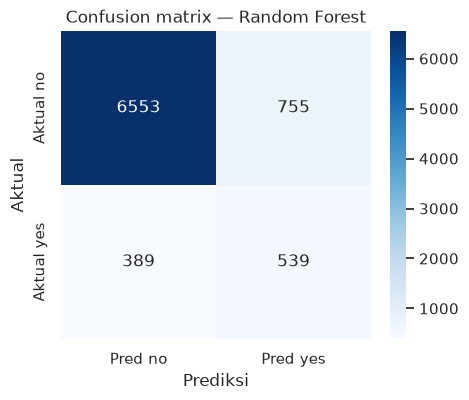

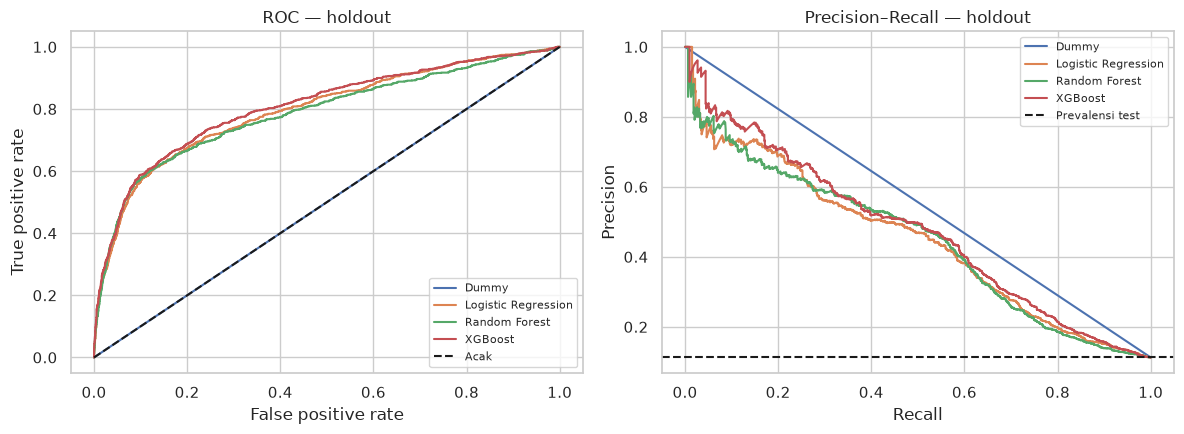

FP=755, FN=389, prevalensi test=11.27%


In [20]:
test_rows, prediction_rows = [], []
for model_name, pipeline in trained_pipelines.items():
    prob = positive_prob(pipeline, X_test)
    pred = (prob >= 0.5).astype(int)
    test_rows.append({'model': model_name, **scores(y_test, prob)})
    prediction_rows.append(pd.DataFrame({'original_index': X_test.index, 'model': model_name,
                                          'y_true': y_test.to_numpy(), 'probability_yes': prob,
                                          'y_pred': pred}))
test_metrics = pd.DataFrame(test_rows)
test_predictions = pd.concat(prediction_rows, ignore_index=True)
test_metrics.to_csv(ART / 'test_metrics.csv', index=False)
test_predictions.to_csv(ART / 'test_predictions.csv', index=False)
display(test_metrics.round(4))
chosen_predictions = test_predictions[test_predictions.model == best_model_name]
matrix = confusion_matrix(chosen_predictions.y_true, chosen_predictions.y_pred, labels=[0,1])
assert matrix.sum() == len(X_test)
print('Model dari CV:', best_model_name)
print(classification_report(chosen_predictions.y_true, chosen_predictions.y_pred,
                            labels=[0,1], target_names=['no','yes'], zero_division=0))
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred no','Pred yes'], yticklabels=['Aktual no','Aktual yes'])
ax.set(title='Confusion matrix — ' + best_model_name, xlabel='Prediksi', ylabel='Aktual')
save_fig('07_confusion_matrix.png')
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
for model_name in estimators:
    sub = test_predictions[test_predictions.model == model_name]
    fpr, tpr, _ = roc_curve(sub.y_true, sub.probability_yes)
    precision, recall, _ = precision_recall_curve(sub.y_true, sub.probability_yes)
    axes[0].plot(fpr,tpr,label=model_name)
    axes[1].plot(recall,precision,label=model_name)
axes[0].plot([0,1],[0,1],'k--',label='Acak')
axes[1].axhline(y_test.mean(),color='k',ls='--',label='Prevalensi test')
axes[0].set(title='ROC — holdout',xlabel='False positive rate',ylabel='True positive rate')
axes[1].set(title='Precision–Recall — holdout',xlabel='Recall',ylabel='Precision')
for ax in axes: 
    ax.legend(fontsize=8)
fig.tight_layout()
save_fig('08_roc_pr.png')
print(f'FP={matrix[0,1]}, FN={matrix[1,0]}, prevalensi test={y_test.mean():.2%}')

## 10. Feature Importance
Importance diambil dari model **terpilih** dan nama fitur preprocessor milik pipeline fitted tersebut. Koefisien LR pada numerik berskala standar, sedangkan kategori adalah kontras terhadap kategori lain pada one-hot. Untuk Random Forest, `feature_importances_` adalah *mean decrease in impurity*: penurunan impurity saat fitur dipakai untuk split, dirata-ratakan antarpohon dan dinormalisasi. Ukuran ini dapat lebih mengutamakan fitur numerik atau kategori dengan banyak titik split; fitur berkorelasi dapat berbagi importance. Importance tree tidak memberi arah pengaruh. Semua ini adalah kontribusi prediktif, bukan efek kausal.

,feature,importance,abs_importance,method
6,num__euribor3m,0.137972,0.137972,mean decrease in impurity
0,num__age,0.106502,0.106502,mean decrease in impurity
7,num__nr.employed,0.085384,0.085384,mean decrease in impurity
3,num__emp.var.rate,0.063481,0.063481,mean decrease in impurity
1,num__campaign,0.057575,0.057575,mean decrease in impurity
5,num__cons.conf.idx,0.039636,0.039636,mean decrease in impurity
4,num__cons.price.idx,0.033558,0.033558,mean decrease in impurity
8,num__was_previously_contacted,0.022522,0.022522,mean decrease in impurity
9,num__pdays_clean,0.020827,0.020827,mean decrease in impurity
44,cat__contact_telephone,0.015965,0.015965,mean decrease in impurity


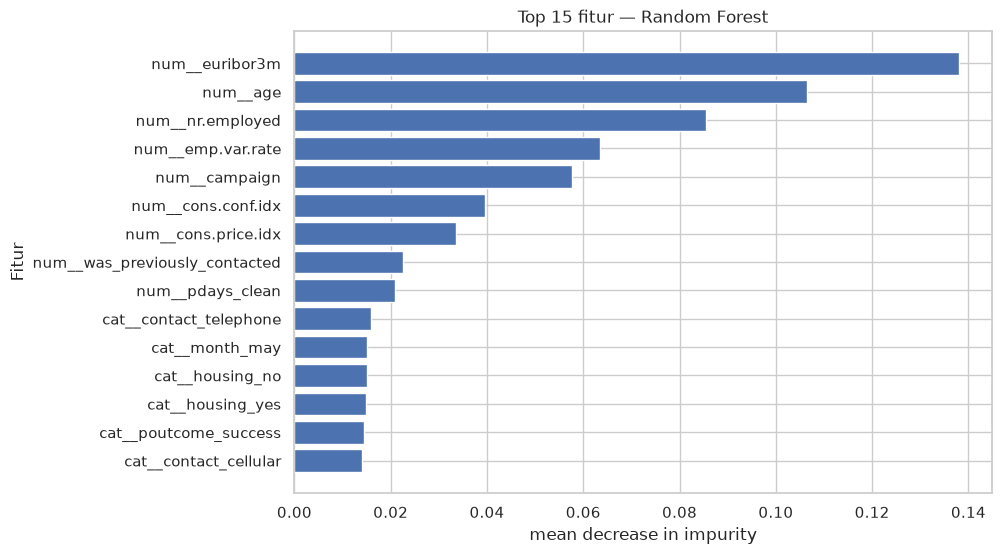

Lima fitur teratas: num__euribor3m, num__age, num__nr.employed, num__emp.var.rate, num__campaign
euribor3m: importance=0.1380; median development no=4.857, yes=1.266.
age: importance=0.1065; median development no=38.000, yes=37.000.
nr.employed: importance=0.0854; median development no=5195.800, yes=5099.100.
emp.var.rate: importance=0.0635; median development no=1.100, yes=-1.800.
campaign: importance=0.0576; median development no=2.000, yes=2.000.
Median/rate di atas hanya konteks deskriptif; kesamaan median tidak meniadakan pola nonlinier.
Importance tree tidak memberi arah efek dan bukan bukti kausal; fitur numerik serta fitur berkorelasi dapat memperoleh ranking yang bias.


In [21]:
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
model = best_pipeline.named_steps['model']
if best_model_name == 'Logistic Regression':
    values = model.coef_[0]
    importance_method = 'signed logistic coefficient'
else:
    values = model.feature_importances_
    importance_method = ('mean decrease in impurity' if best_model_name == 'Random Forest'
                         else 'XGBoost feature_importances_ (gain)')
assert len(feature_names) == len(values)
feature_importance = pd.DataFrame({'feature': feature_names, 'importance': values,
                                   'abs_importance': np.abs(values), 'method': importance_method})
feature_importance = feature_importance.sort_values('abs_importance', ascending=False)
feature_importance.to_csv(ART / 'feature_importance.csv', index=False)
display(feature_importance.head(15))
fig, ax = plt.subplots(figsize=(9,6))
top = feature_importance.head(15).iloc[::-1]
ax.barh(top.feature, top.importance if best_model_name == 'Logistic Regression' else top.abs_importance)
ax.set(title='Top 15 fitur — ' + best_model_name, xlabel=importance_method, ylabel='Fitur')
save_fig('09_feature_importance.png')
print('Lima fitur teratas:', ', '.join(feature_importance.feature.head(5)))
for row in feature_importance.head(5).itertuples():
    encoded = row.feature
    if encoded.startswith('num__'):
        raw = encoded.removeprefix('num__')
        medians = eda.groupby('y')[raw].median()
        print(f'{raw}: importance={row.importance:.4f}; median development no={medians.loc[0]:.3f}, yes={medians.loc[1]:.3f}.')
    else:
        suffix = encoded.removeprefix('cat__')
        raw = next((name for name in categorical_features if suffix.startswith(name + '_')), None)
        if raw is None:
            raise ValueError(f'Kategori encoding tidak dikenal: {encoded}')
        category = suffix[len(raw)+1:]
        subset = eda[eda[raw].astype(str) == category]
        print(f'{raw}={category}: importance={row.importance:.4f}; n={len(subset)}, rate yes={subset.y.mean():.3f} pada development.')
print('Median/rate di atas hanya konteks deskriptif; kesamaan median tidak meniadakan pola nonlinier.')
print('Importance tree tidak memberi arah efek dan bukan bukti kausal; fitur numerik serta fitur berkorelasi dapat memperoleh ranking yang bias.')

## 11. Conclusion & Recommendations
Kesimpulan numerik berikut dibangkitkan langsung dari artefak dalam memori. Rekomendasi bersifat langkah evaluasi, bukan klaim penghematan atau efek kausal kanal/bulan tertentu. Generalisasi dibatasi satu bank dan periode historis; split acak bergrup tidak menguji masa depan, tidak ada ID nasabah, dan ketersediaan fitur perlu diaudit. Kelas tidak seimbang, threshold 0,5 belum dioptimalkan terhadap biaya, probabilitas berbobot belum dikalibrasi, dan importance tidak kausal. Validasi temporal, kalibrasi, audit bias atribut demografi, serta pengukuran biaya FP/FN adalah pekerjaan lanjutan.

In [22]:
chosen = test_metrics.set_index('model').loc[best_model_name]
baseline_cv = means['Dummy']
verdict = ('memberi bukti perbaikan atas baseline' if means[best_model_name] > baseline_cv
           else 'belum memberi bukti perbaikan atas baseline')
other_candidates = test_metrics[test_metrics.model.isin(
    [name for name in candidate_order if name != best_model_name])].set_index('model')
comparison_name = other_candidates.ap.idxmax()
comparison = other_candidates.loc[comparison_name]
display(Markdown(f'''**{best_model_name}** {verdict}: mean CV F1 **{means[best_model_name]:.3f}**
versus baseline **{baseline_cv:.3f}**. Pada holdout, F1 **{chosen.f1:.3f}**, precision
**{chosen.precision:.3f}**, recall **{chosen.recall:.3f}**, ROC-AUC **{chosen.roc_auc:.3f}**,
dan AP **{chosen.ap:.3f}**. Confusion matrix mencatat **{matrix[0,1]} FP** dan
**{matrix[1,0]} FN**. Sebagai pembanding deskriptif pada holdout, {comparison_name} memiliki
precision **{comparison.precision:.3f}**, recall **{comparison.recall:.3f}**, dan AP
**{comparison.ap:.3f}**. Model terpilih mengutamakan F1 validasi; angka holdout ini
tidak dipakai untuk memilih ulang model. Lima fitur teratas menurut {importance_method}:
{', '.join(feature_importance.feature.head(5))}. Ini kontribusi prediktif, bukan sebab akibat.

**Rekomendasi:** (1) Bila bukti cukup, uji pilot prioritisasi dalam kapasitas kontak terbatas
dengan pemantauan FP/FN; (2) hitung biaya riil kedua kesalahan sebelum mengubah threshold;
(3) audit ketersediaan fitur dan lakukan validasi temporal pada data terbaru sebelum penggunaan nyata;
(4) uji perubahan kanal atau jadwal dengan eksperimen terpisah, bukan berdasarkan asosiasi historis.'''))
run_metadata = {
    'run_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(), 'platform': platform.platform(),
    'library_versions': {name: metadata.version(name) for name in
                         ['pandas','numpy','matplotlib','seaborn','scikit-learn','xgboost',
                          'jupyter_core','nbformat','nbconvert','ipykernel','reportlab','pypdf']},
    'random_state': RANDOM_STATE, 'source_csv_sha256': csv_sha,
    'raw_shape': list(df_raw.shape), 'clean_rows': len(df_clean),
    'development_rows': len(X_train), 'test_rows': len(X_test),
    'best_model_name': best_model_name,
}
(ART / 'run_metadata.json').write_text(json.dumps(run_metadata, indent=2) + '\n')

**Random Forest** memberi bukti perbaikan atas baseline: mean CV F1 **0.493**
versus baseline **0.000**. Pada holdout, F1 **0.485**, precision
**0.417**, recall **0.581**, ROC-AUC **0.786**,
dan AP **0.446**. Confusion matrix mencatat **755 FP** dan
**389 FN**. Sebagai pembanding deskriptif pada holdout, XGBoost memiliki
precision **0.366**, recall **0.629**, dan AP
**0.474**. Model terpilih mengutamakan F1 validasi; angka holdout ini
tidak dipakai untuk memilih ulang model. Lima fitur teratas menurut mean decrease in impurity:
num__euribor3m, num__age, num__nr.employed, num__emp.var.rate, num__campaign. Ini kontribusi prediktif, bukan sebab akibat.

**Rekomendasi:** (1) Bila bukti cukup, uji pilot prioritisasi dalam kapasitas kontak terbatas
dengan pemantauan FP/FN; (2) hitung biaya riil kedua kesalahan sebelum mengubah threshold;
(3) audit ketersediaan fitur dan lakukan validasi temporal pada data terbaru sebelum penggunaan nyata;
(4) uji perubahan kanal atau jadwal dengan eksperimen terpisah, bukan berdasarkan asosiasi historis.

737